In [41]:
# Verify we're in the correct conda environment
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Check if alphagenome-env is active
if 'alphagenome-env' not in sys.executable:
    print("\n⚠️  WARNING: Not in alphagenome-env conda environment!")
    print("   Run this in terminal first:")
    print("   conda activate alphagenome-env")
    print("   Then restart the Jupyter kernel")
else:
    print("✓ Running in alphagenome-env")

Python executable: /opt/conda/envs/alphagenome-env/bin/python
Python version: 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:46:25) [GCC 14.3.0]
✓ Running in alphagenome-env


## Setup

In [42]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add scripts directory to path
sys.path.insert(0, str(Path.cwd() / 'scripts'))

# Import variant definitions
from experimental_variants_data import EXPERIMENTAL_VARIANTS, ALL_OUTPUTS

# Import AlphaGenome
from alphagenome.data import genome
from alphagenome.models import dna_client, variant_scorers

# Setup plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports loaded")
print(f"✓ Found {len(EXPERIMENTAL_VARIANTS)} experimental variants")
print(f"✓ AlphaGenome context window: {dna_client.SEQUENCE_LENGTH_1MB:,} bp")
print(f"✓ Available scorers: {list(variant_scorers.RECOMMENDED_VARIANT_SCORERS.keys())}")

✓ Imports loaded
✓ Found 15 experimental variants
✓ AlphaGenome context window: 1,048,576 bp
✓ Available scorers: ['ATAC', 'CONTACT_MAPS', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'PROCAP', 'RNA_SEQ', 'RNA_SEQ_ACTIVE', 'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS', 'POLYADENYLATION', 'ATAC_ACTIVE', 'DNASE_ACTIVE', 'CHIP_TF_ACTIVE', 'CHIP_HISTONE_ACTIVE', 'CAGE_ACTIVE', 'PROCAP_ACTIVE']


## 1. Filter to FCGR2B and GBP1 Variants Only

In [43]:
# Filter variants
immune_variants = [v for v in EXPERIMENTAL_VARIANTS if v['gene'] in ['FCGR2B', 'GBP1']]

# Organize by gene
fcgr2b_variants = [v for v in immune_variants if v['gene'] == 'FCGR2B']
gbp1_variants = [v for v in immune_variants if v['gene'] == 'GBP1']

print(f"Total immune gene variants: {len(immune_variants)}")
print(f"  FCGR2B: {len(fcgr2b_variants)} variants")
print(f"  GBP1: {len(gbp1_variants)} variants")
print("\n" + "="*80)

# Display variant details
print("\nFCGR2B Variants:")
for v in fcgr2b_variants:
    print(f"  {v['position']:,} {v['ref']}→{v['alt']} [{v['type']}] {v['sample']} {v['genotype']}")

print("\nGBP1 Variants:")
for v in gbp1_variants:
    print(f"  {v['position']:,} {v['ref']}→{v['alt']} [{v['type']}] {v['sample']} {v['genotype']}")

Total immune gene variants: 10
  FCGR2B: 5 variants
  GBP1: 5 variants


FCGR2B Variants:
  161,506,414 C→T [5_prime_UTR_variant] HG002_chr1 homozygous_alt
  161,506,414 C→T [5_prime_UTR_variant] HG004_chr1 heterozygous
  161,506,414 C→T [5_prime_UTR_variant] HG003_chr1 heterozygous
  161,509,955 A→G [missense_variant] HG003_chr1 heterozygous
  161,506,415 A→G [5_prime_UTR_variant] HG002_chr1 homozygous_alt

GBP1 Variants:
  89,014,075 T→C [splice_variant] HG002_chr1 homozygous_alt
  89,014,075 T→C [splice_variant] HG003_chr1 homozygous_alt
  89,014,075 T→C [splice_variant] HG004_chr1 heterozygous
  89,013,380 G→A [missense_variant] HG002_chr1 heterozygous
  89,013,391 C→T [missense_variant] HG002_chr1 heterozygous


## 2. Initialize AlphaGenome Client

In [44]:
# Check for API key and initialize client
api_key = os.getenv('ALPHA_GENOME_KEY')

if not api_key:
    print("⚠️  ALPHA_GENOME_KEY not set!")
    print("   Set it in this cell:")
    print("   os.environ['ALPHA_GENOME_KEY'] = 'your-key-here'")
    raise ValueError("AlphaGenome API key is required")

print(f"✓ AlphaGenome API key found ({api_key[:10]}...)")

# Initialize client using dna_client.create()
client = dna_client.create(api_key)
print("✓ AlphaGenome DnaClient initialized")
print(f"✓ Client type: {type(client)}")

✓ AlphaGenome API key found (AIzaSyDYc_...)
✓ AlphaGenome DnaClient initialized
✓ Client type: <class 'alphagenome.models.dna_client.DnaClient'>


## 3. REF vs ALT Prediction Function

Generate predictions for both reference and alternate alleles, then calculate differences.

In [45]:
def get_ref_alt_predictions(client, variant_dict):
    """
    Generate REF and ALT predictions for a variant using AlphaGenome.
    
    Parameters:
    -----------
    client : DnaClient
        AlphaGenome client instance
    variant_dict : dict
        Variant definition with chromosome, position, ref, alt keys
    
    Returns:
    --------
    dict with keys: ref_scores, alt_scores, comparison_df, metadata
    """
    chrom = variant_dict['chromosome']
    pos = variant_dict['position']
    ref = variant_dict['ref']
    alt = variant_dict['alt']
    
    try:
        # Create AlphaGenome Variant objects
        # REF variant (reference allele at position)
        ref_variant = genome.Variant(
            chromosome=chrom,
            position=pos,
            reference_bases=ref,
            alternate_bases=ref,  # Use ref as alt to get baseline
            name=f"{chrom}:{pos}:{ref}>REF"
        )
        
        # ALT variant (alternate allele at position)
        alt_variant = genome.Variant(
            chromosome=chrom,
            position=pos,
            reference_bases=ref,
            alternate_bases=alt,
            name=f"{chrom}:{pos}:{ref}>{alt}"
        )
        
        # Get 1MB interval around variant
        interval = ref_variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)
        
        # Use all recommended scorers to capture multi-modal features
        scorers = list(variant_scorers.RECOMMENDED_VARIANT_SCORERS.values())
        organism = dna_client.Organism.HOMO_SAPIENS
        
        # Score REF variant
        ref_scores = client.score_variant(
            interval=interval,
            variant=ref_variant,
            variant_scorers=scorers,
            organism=organism
        )
        
        # Score ALT variant
        alt_scores = client.score_variant(
            interval=interval,
            variant=alt_variant,
            variant_scorers=scorers,
            organism=organism
        )
        
        # Convert to tidy dataframes
        ref_df = variant_scorers.tidy_scores(ref_scores)
        alt_df = variant_scorers.tidy_scores(alt_scores)
        
        # Add labels
        ref_df['allele'] = 'REF'
        alt_df['allele'] = 'ALT'
        
        # Combine for comparison
        comparison_df = pd.concat([ref_df, alt_df], ignore_index=True)
        
        # Calculate deltas by track
        track_deltas = []
        for track_name in ref_df['track_name'].unique():
            ref_score = ref_df[ref_df['track_name'] == track_name]['quantile_score'].values
            alt_score = alt_df[alt_df['track_name'] == track_name]['quantile_score'].values
            
            if len(ref_score) > 0 and len(alt_score) > 0:
                delta = abs(alt_score[0] - ref_score[0])
                track_deltas.append({
                    'track_name': track_name,
                    'output_type': ref_df[ref_df['track_name'] == track_name]['output_type'].values[0],
                    'ref_score': ref_score[0],
                    'alt_score': alt_score[0],
                    'delta': delta
                })
        
        deltas_df = pd.DataFrame(track_deltas)
        
        return {
            'success': True,
            'ref_scores': ref_scores,
            'alt_scores': alt_scores,
            'ref_df': ref_df,
            'alt_df': alt_df,
            'comparison_df': comparison_df,
            'deltas_df': deltas_df,
            'max_delta': deltas_df['delta'].max() if len(deltas_df) > 0 else None,
            'mean_delta': deltas_df['delta'].mean() if len(deltas_df) > 0 else None,
            'num_tracks': len(deltas_df)
        }
    
    except Exception as e:
        import traceback
        return {
            'success': False,
            'error': str(e),
            'traceback': traceback.format_exc()
        }

print("✓ REF vs ALT scoring function defined")
print("  Uses AlphaGenome score_variant() API")
print("  Captures all recommended scorers (RNA_SEQ, ATAC, CAGE, etc.)")
print("  Returns quantile scores and deltas per track")

✓ REF vs ALT scoring function defined
  Uses AlphaGenome score_variant() API
  Captures all recommended scorers (RNA_SEQ, ATAC, CAGE, etc.)
  Returns quantile scores and deltas per track


## 4. Generate All Predictions

This will take some time - we're generating REF and ALT predictions for 10 variants × 6 tracks = 60 prediction pairs (120 API calls).

In [46]:
# Storage for results
results = {}

# Generate predictions
print(f"Scoring {len(immune_variants)} variants with AlphaGenome...\n")
print(f"Each variant will be scored across ~89K tracks")
print(f"This will take approximately {len(immune_variants) * 2} minutes\n")

for variant in immune_variants:
    variant_key = f"{variant['gene']}_{variant['position']}"
    
    print(f"\n{'='*80}")
    print(f"Processing: {variant['name']}")
    print(f"  {variant['chromosome']}:{variant['position']} {variant['ref']}→{variant['alt']}")
    print(f"{'='*80}")
    
    result = get_ref_alt_predictions(client, variant)
    results[variant_key] = result
    
    if result['success']:
        print(f"✓ Success!")
        print(f"  Tracks scored: {result['num_tracks']:,}")
        print(f"  Max Δ: {result['max_delta']:.4f}")
        print(f"  Mean Δ: {result['mean_delta']:.4f}")
    else:
        print(f"❌ Failed: {result['error']}")
        print(result.get('traceback', ''))

print("\n" + "="*80)
print("✓ All variants scored!")
print("="*80)

Scoring 10 variants with AlphaGenome...

Each variant will be scored across ~89K tracks
This will take approximately 20 minutes


Processing: FCGR2B_HG002_chr1_pos161506414
  chr1:161506414 C→T
✓ Success!
  Tracks scored: 4,619
  Max Δ: 1.1605
  Mean Δ: 0.6912

Processing: FCGR2B_HG004_chr1_pos161506414
  chr1:161506414 C→T
✓ Success!
  Tracks scored: 4,619
  Max Δ: 1.1605
  Mean Δ: 0.6912

Processing: FCGR2B_HG004_chr1_pos161506414
  chr1:161506414 C→T
✓ Success!
  Tracks scored: 4,619
  Max Δ: 1.1417
  Mean Δ: 0.6918

Processing: FCGR2B_HG003_chr1_pos161506414
  chr1:161506414 C→T
✓ Success!
  Tracks scored: 4,619
  Max Δ: 1.1417
  Mean Δ: 0.6918

Processing: FCGR2B_HG003_chr1_pos161506414
  chr1:161506414 C→T
✓ Success!
  Tracks scored: 4,619
  Max Δ: 1.2040
  Mean Δ: 0.6916

Processing: FCGR2B_HG003_chr1_pos161509955
  chr1:161509955 A→G
✓ Success!
  Tracks scored: 4,619
  Max Δ: 1.2040
  Mean Δ: 0.6916

Processing: FCGR2B_HG003_chr1_pos161509955
  chr1:161509955 A→G
✓ Success!
  T

## 5. Summary Statistics

In [47]:
# Compile summary statistics from all variants
all_deltas = []

for variant_key, result in results.items():
    if result['success'] and 'deltas_df' in result:
        gene = variant_key.split('_')[0]
        position = variant_key.split('_')[1]
        
        deltas_df = result['deltas_df'].copy()
        deltas_df['Gene'] = gene
        deltas_df['Position'] = position
        all_deltas.append(deltas_df)

if len(all_deltas) == 0:
    print("\n⚠️  WARNING: No successful predictions found!")
    print("\nDebugging information:")
    for variant_key, result in results.items():
        print(f"\n{variant_key}:")
        if result['success']:
            print(f"  Success but no deltas_df: {result.keys()}")
        else:
            print(f"  FAILED: {result.get('error', 'unknown error')}")
else:
    # Combine all delta dataframes
    summary_df = pd.concat(all_deltas, ignore_index=True)
    
    print(f"\n✓ Compiled {len(summary_df):,} track-level comparisons")
    print(f"  Unique variants: {summary_df[['Gene', 'Position']].drop_duplicates().shape[0]}")
    print(f"  Unique tracks: {summary_df['track_name'].nunique()}")
    print(f"  Output types: {summary_df['output_type'].unique().tolist()}")
    
    # Summary by output type
    print("\n" + "="*80)
    print("SUMMARY BY OUTPUT TYPE")
    print("="*80)
    output_summary = summary_df.groupby('output_type')['delta'].agg(['count', 'mean', 'max']).round(4)
    print(output_summary)
    
    # Top 20 highest impact changes
    print("\n" + "="*80)
    print("TOP 20 HIGHEST IMPACT REF vs ALT CHANGES")
    print("="*80)
    top_effects = summary_df.nlargest(20, 'delta')
    for idx, row in top_effects.iterrows():
        print(f"{row['Gene']:8s} {row['Position']:>9s} {row['output_type']:20s} {row['track_name'][:40]:40s} Δ = {row['delta']:.4f}")


✓ Compiled 27,714 track-level comparisons
  Unique variants: 6
  Unique tracks: 4619
  Output types: ['ATAC', 'CONTACT_MAPS', 'DNASE', 'CHIP_TF', 'CHIP_HISTONE', 'CAGE', 'PROCAP', 'RNA_SEQ', 'SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS']

SUMMARY BY OUTPUT TYPE
                   count    mean     max
output_type                             
ATAC                1002  0.4642  0.9942
CAGE                1638  0.8452  1.0459
CHIP_HISTONE        6696  0.5144  1.1478
CHIP_TF             9702  0.4859  1.2040
CONTACT_MAPS         168  0.8265  0.9515
DNASE               1830  0.5347  1.0089
PROCAP                36  0.6699  0.8972
RNA_SEQ             2226  0.5510  0.9876
SPLICE_JUNCTIONS    2202  0.9500  0.9993
SPLICE_SITES          12  0.7515  0.9892
SPLICE_SITE_USAGE   2202  0.8598  0.9988

TOP 20 HIGHEST IMPACT REF vs ALT CHANGES
FCGR2B   161506414 CHIP_TF              EFO:0002793 TF ChIP-seq CTCF             Δ = 1.2040
FCGR2B   161506414 CHIP_HISTONE         UBERON:0001987 Histo

## 6. Visualize Track-by-Track Comparison

Heatmap showing max delta for each variant × track combination.

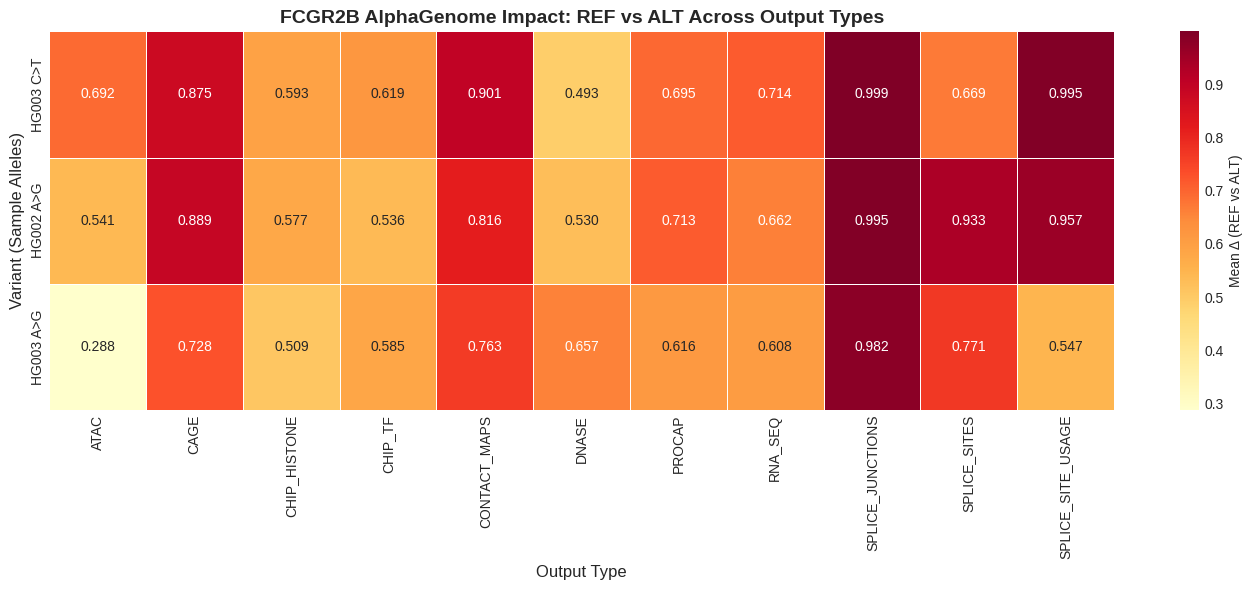

✓ FCGR2B heatmap saved to outputs/FCGR2B_track_heatmap.png
  3 variants × 11 output types



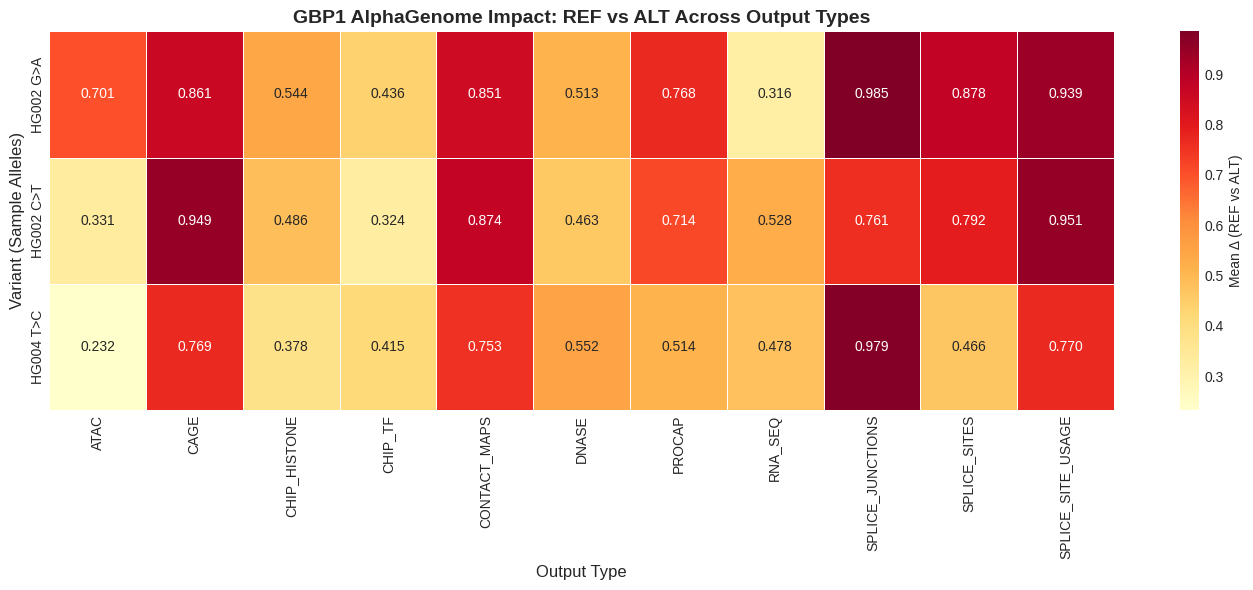

✓ GBP1 heatmap saved to outputs/GBP1_track_heatmap.png
  3 variants × 11 output types


✓ Individual gene heatmaps complete!


In [53]:
# Create separate heatmaps for each gene
for target_gene in ['FCGR2B', 'GBP1']:
    # Filter data for this gene
    gene_df = summary_df[summary_df['Gene'] == target_gene].copy()
    
    if len(gene_df) == 0:
        print(f"⚠️  No data for {target_gene}")
        continue
    
    # Create pivot table for heatmap - aggregate by output_type
    pivot_df = gene_df.groupby(['Gene', 'Position', 'output_type'])['delta'].mean().reset_index()
    pivot_df = pivot_df.pivot_table(
        index=['Gene', 'Position'],
        columns='output_type',
        values='delta',
        aggfunc='mean'
    )
    
    # Create better row labels with sample info
    position_to_sample = {}
    for v in immune_variants:
        if v['gene'] == target_gene:
            key = (v['gene'], str(v['position']))
            sample = v['sample'].replace('_chr1', '')  # Extract HG002, HG003, HG004
            ref_alt = f"{v['ref']}>{v['alt']}"
            position_to_sample[key] = (sample, ref_alt)
    
    # Create informative labels: "HG002 C>T"
    row_labels = []
    for gene, pos in pivot_df.index:
        sample, ref_alt = position_to_sample.get((gene, pos), ('', ''))
        row_labels.append(f"{sample} {ref_alt}")
    
    pivot_df.index = row_labels
    
    # Plot heatmap
    fig_height = max(6, len(pivot_df) * 1.2)  # Scale height based on variants
    plt.figure(figsize=(14, fig_height))
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='YlOrRd', 
                cbar_kws={'label': 'Mean Δ (REF vs ALT)'}, linewidths=0.5)
    plt.title(f'{target_gene} AlphaGenome Impact: REF vs ALT Across Output Types', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Output Type', fontsize=12)
    plt.ylabel('Variant (Sample Alleles)', fontsize=12)
    plt.tight_layout()
    
    output_file = f'outputs/{target_gene}_track_heatmap.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ {target_gene} heatmap saved to {output_file}")
    print(f"  {len(pivot_df)} variants × {len(pivot_df.columns)} output types")
    print()

print("\n✓ Individual gene heatmaps complete!")

## 7. Gene-Level Comparison

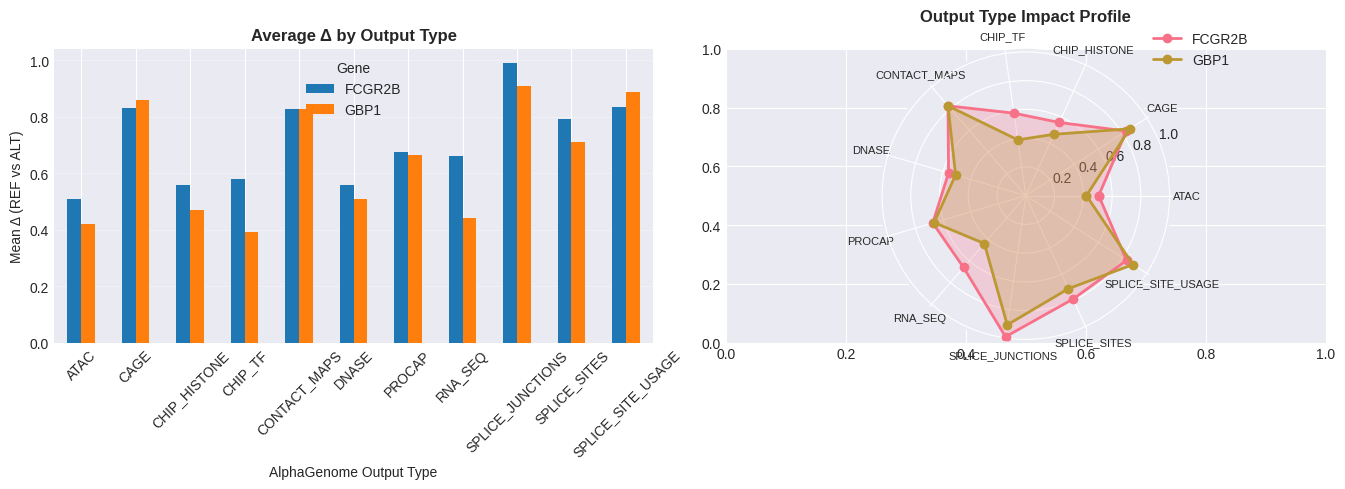

✓ Gene comparison saved to outputs/FCGR2B_GBP1_gene_comparison.png


In [49]:
# Compare FCGR2B vs GBP1 across output types
gene_comparison = summary_df.groupby(['Gene', 'output_type'])['delta'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
gene_comparison.T.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Average Δ by Output Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('AlphaGenome Output Type')
axes[0].set_ylabel('Mean Δ (REF vs ALT)')
axes[0].legend(title='Gene')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Radar plot
from math import pi

output_types = gene_comparison.columns.tolist()
num_types = len(output_types)
angles = [n / float(num_types) * 2 * pi for n in range(num_types)]
angles += angles[:1]

ax = plt.subplot(122, polar=True)
for gene in ['FCGR2B', 'GBP1']:
    if gene in gene_comparison.index:
        values = gene_comparison.loc[gene].tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=gene)
        ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(output_types, size=8)
ax.set_title('Output Type Impact Profile', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('outputs/FCGR2B_GBP1_gene_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gene comparison saved to outputs/FCGR2B_GBP1_gene_comparison.png")

## 7a. Per-Variant Output Type Impact Profiles

Radar plots showing the impact profile for each individual variant.

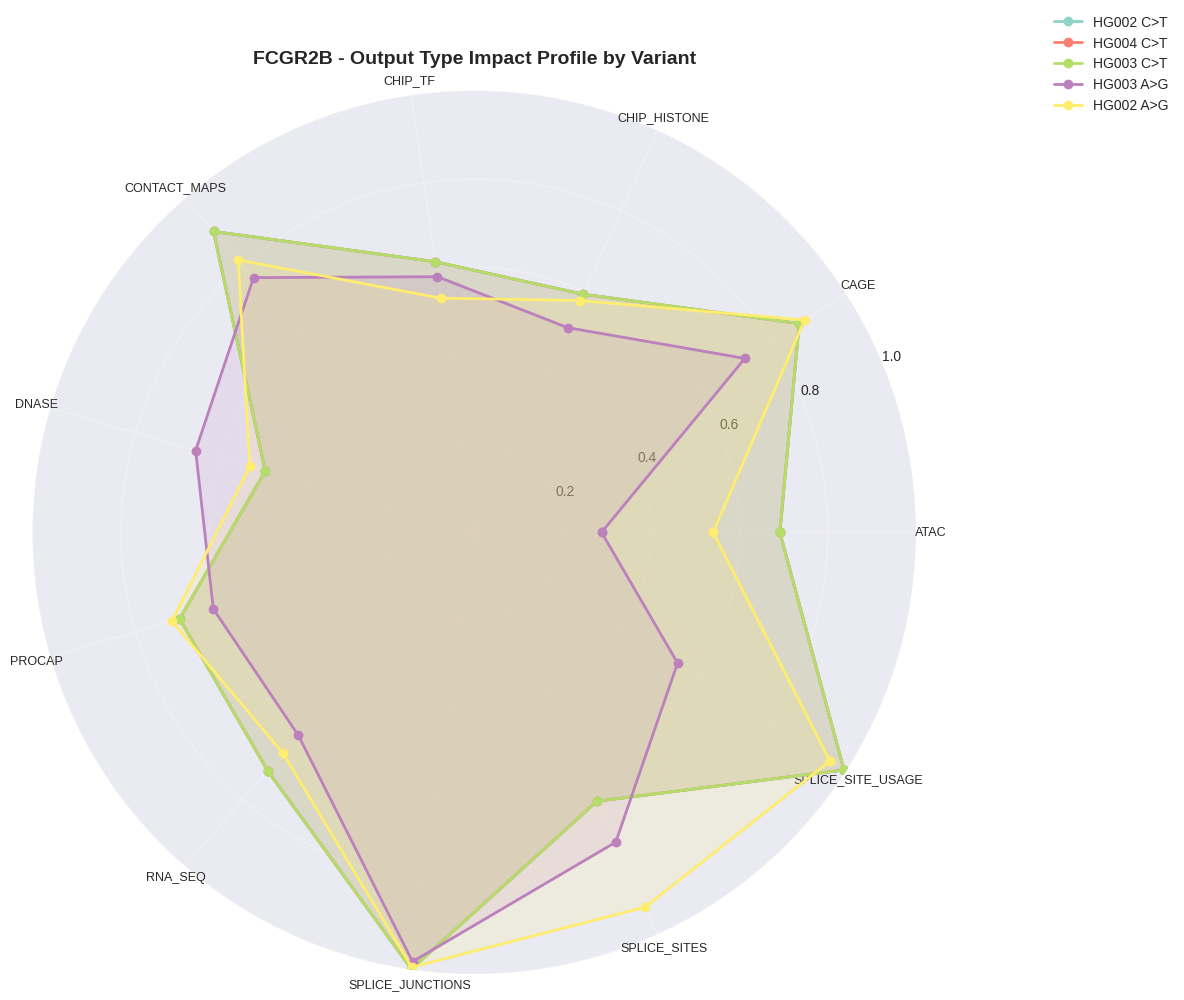

✓ FCGR2B variant radar plot saved to outputs/FCGR2B_variant_radar.png
  5 variants across 11 output types



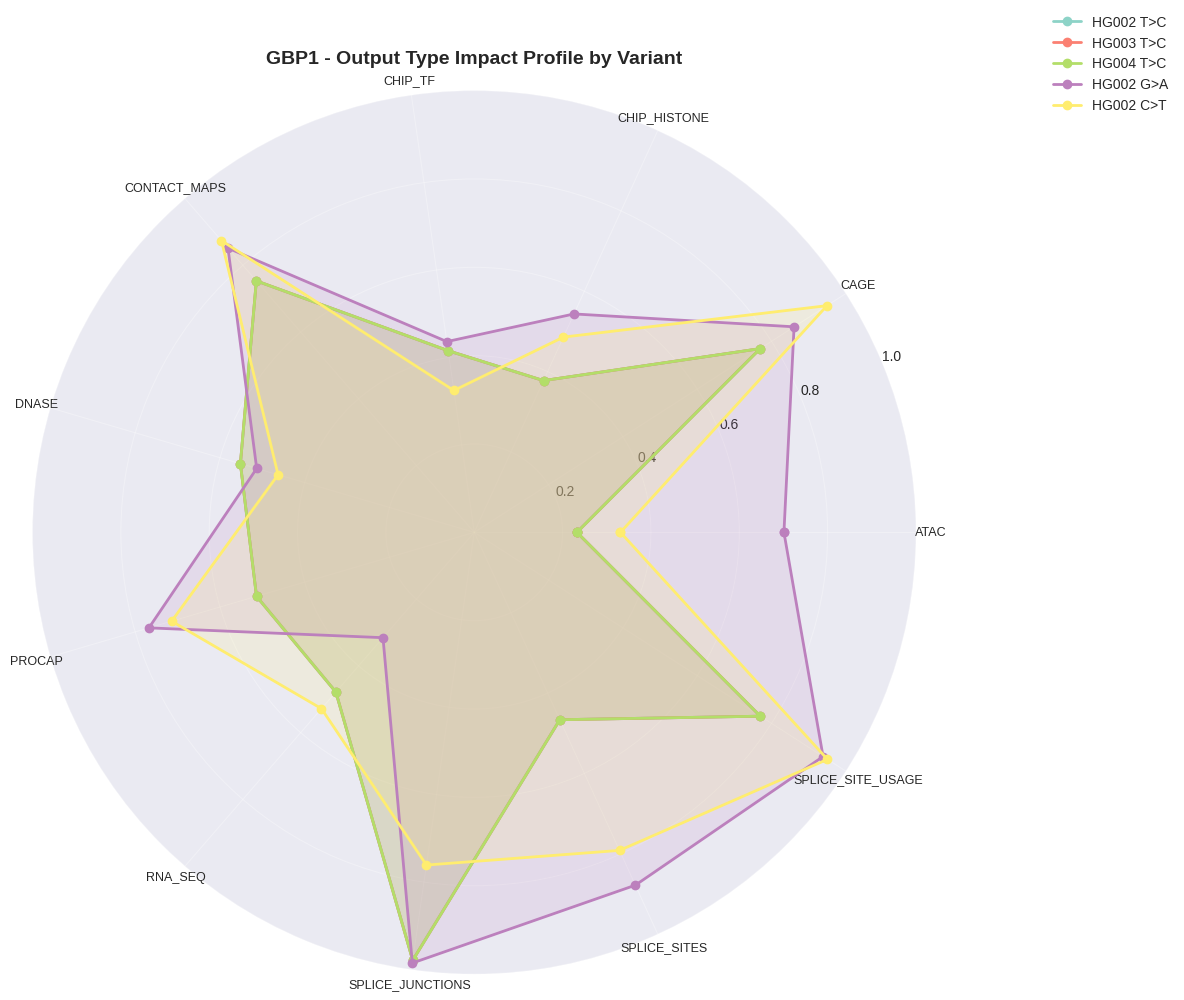

✓ GBP1 variant radar plot saved to outputs/GBP1_variant_radar.png
  5 variants across 11 output types


✓ Per-variant radar plots complete!


In [56]:
# Create individual radar plots for each gene showing all variants
from math import pi

for target_gene in ['FCGR2B', 'GBP1']:
    # Filter data for this gene
    gene_df = summary_df[summary_df['Gene'] == target_gene].copy()
    
    if len(gene_df) == 0:
        print(f"⚠️  No data for {target_gene}")
        continue
    
    # Get unique variants for this gene
    gene_variants = [v for v in immune_variants if v['gene'] == target_gene]
    
    # Calculate mean delta by variant and output type
    variant_output = gene_df.groupby(['Position', 'output_type'])['delta'].mean().unstack(fill_value=0)
    
    # Get output types
    output_types = variant_output.columns.tolist()
    num_types = len(output_types)
    angles = [n / float(num_types) * 2 * pi for n in range(num_types)]
    angles += angles[:1]
    
    # Create figure
    fig = plt.figure(figsize=(14, 10))
    ax = plt.subplot(111, polar=True)
    
    # Color palette for variants
    colors = plt.cm.Set3(np.linspace(0, 1, len(gene_variants)))
    
    # Plot each variant
    for idx, variant in enumerate(gene_variants):
        pos = str(variant['position'])
        sample = variant['sample'].replace('_chr1', '')
        ref_alt = f"{variant['ref']}>{variant['alt']}"
        label = f"{sample} {ref_alt}"
        
        if pos in variant_output.index:
            values = variant_output.loc[pos].tolist()
            values += values[:1]
            
            ax.plot(angles, values, 'o-', linewidth=2, label=label, color=colors[idx])
            ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    # Configure plot
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(output_types, size=9)
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{target_gene} - Output Type Impact Profile by Variant', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    output_file = f'outputs/{target_gene}_variant_radar.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ {target_gene} variant radar plot saved to {output_file}")
    print(f"  {len(gene_variants)} variants across {num_types} output types")
    print()

print("\n✓ Per-variant radar plots complete!")

## 8. Identify Most Affected Biological Processes


BIOLOGICAL PROCESSES MOST AFFECTED BY REF→ALT CHANGES
                                  delta              
                                   mean     max count
Gene   Process                                       
FCGR2B RNA Splicing              0.9906  0.9993  1107
GBP1   RNA Splicing              0.9072  0.9910  1107
       Other                     0.8864  0.9939  1101
       Transcription Initiation  0.8556  1.0088   837
FCGR2B Other                     0.8332  0.9988  1101
       Transcription Initiation  0.8273  1.0459   837
       3D Genome Organization    0.8268  0.9493    84
GBP1   3D Genome Organization    0.8263  0.9515    84
FCGR2B Gene Expression           0.6613  0.9876  1113
       TF Binding                0.5797  1.2040  4851
       Epigenetic Regulation     0.5597  1.1478  3348
       Chromatin Accessibility   0.5413  0.9937  1416
GBP1   Chromatin Accessibility   0.4783  1.0089  1416
       Epigenetic Regulation     0.4690  1.0732  3348
       Gene Expression     

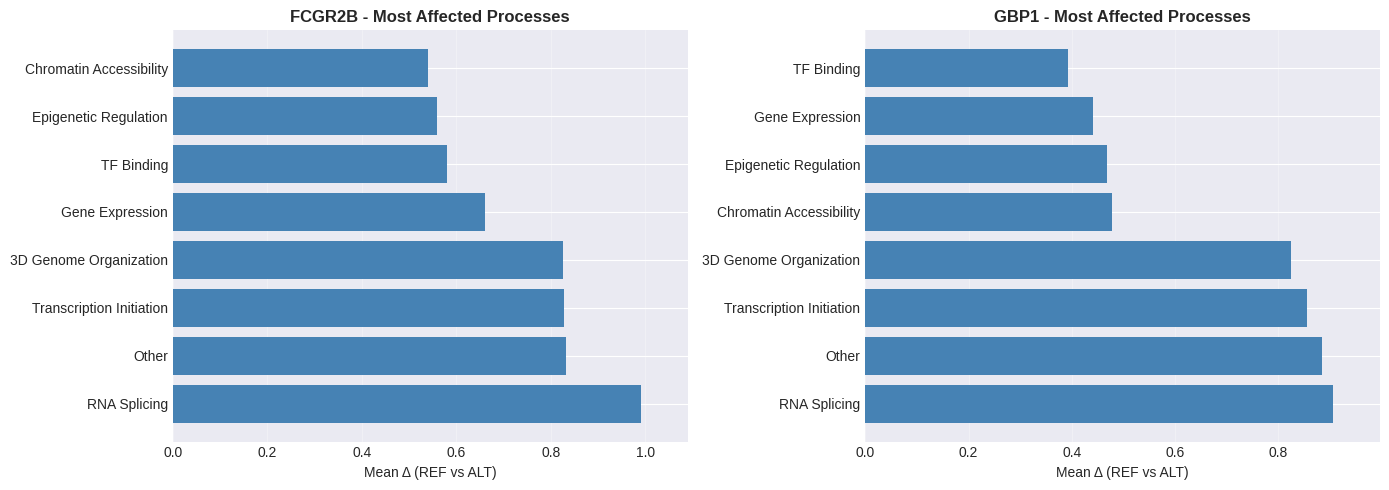


✓ Process impact saved to outputs/FCGR2B_GBP1_process_impact.png


In [50]:
# Define biological process mapping for output types
output_to_process = {
    'RNA_SEQ': 'Gene Expression',
    'ATAC': 'Chromatin Accessibility',
    'DNASE': 'Chromatin Accessibility',
    'CAGE': 'Transcription Initiation',
    'PROCAP': 'Transcription Initiation',
    'CHIP_TF': 'TF Binding',
    'CHIP_HISTONE': 'Epigenetic Regulation',
    'CONTACT_MAPS': '3D Genome Organization',
    'SPLICE_JUNCTIONS': 'RNA Splicing',
    'SPLICE_SITES': 'RNA Splicing',
    'SPLICE_USAGE': 'RNA Splicing'
}

# Map output types to processes
process_impact = summary_df.copy()
process_impact['Process'] = process_impact['output_type'].map(output_to_process)
process_impact['Process'] = process_impact['Process'].fillna('Other')

# Calculate average impact per process
process_summary = process_impact.groupby(['Gene', 'Process']).agg({
    'delta': ['mean', 'max', 'count']
}).round(4)

print("\n" + "="*80)
print("BIOLOGICAL PROCESSES MOST AFFECTED BY REF→ALT CHANGES")
print("="*80)
print(process_summary.sort_values(('delta', 'mean'), ascending=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, gene in enumerate(['FCGR2B', 'GBP1']):
    gene_data = process_impact[process_impact['Gene'] == gene]
    if len(gene_data) > 0:
        process_means = gene_data.groupby('Process')['delta'].mean().sort_values(ascending=False)
        
        axes[idx].barh(process_means.index, process_means.values, color='steelblue')
        axes[idx].set_title(f'{gene} - Most Affected Processes', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Mean Δ (REF vs ALT)')
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].set_xlim(0, process_means.max() * 1.1)

plt.tight_layout()
plt.savefig('outputs/FCGR2B_GBP1_process_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Process impact saved to outputs/FCGR2B_GBP1_process_impact.png")

## 9. Export Results

In [57]:
# Create outputs directory if needed
Path('outputs').mkdir(exist_ok=True)

# Save summary table
summary_df.to_csv('outputs/FCGR2B_GBP1_ref_alt_summary.csv', index=False)
print("✓ Summary table saved to outputs/FCGR2B_GBP1_ref_alt_summary.csv")
print(f"  {len(summary_df):,} rows × {len(summary_df.columns)} columns")

# Save top 100 tracks per variant
top_tracks_per_variant = []
for variant_key in results.keys():
    if results[variant_key]['success']:
        gene, pos = variant_key.split('_')
        variant_top = summary_df[
            (summary_df['Gene'] == gene) & 
            (summary_df['Position'] == pos)
        ].nlargest(100, 'delta')
        top_tracks_per_variant.append(variant_top)

if len(top_tracks_per_variant) > 0:
    top_tracks_df = pd.concat(top_tracks_per_variant, ignore_index=True)
    top_tracks_df.to_csv('outputs/FCGR2B_GBP1_top100_tracks_per_variant.csv', index=False)
    print(f"✓ Top 100 tracks per variant saved ({len(top_tracks_df):,} rows)")

# Save metadata summary
# Convert tuple keys to strings for JSON serialization
tracks_per_variant = summary_df.groupby(['Gene', 'Position'])['track_name'].nunique().to_dict()
tracks_per_variant_str = {f"{gene}_{pos}": count for (gene, pos), count in tracks_per_variant.items()}

metadata = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'num_variants': len(immune_variants),
    'genes': ['FCGR2B', 'GBP1'],
    'total_comparisons': len(summary_df),
    'context_window': f"{dna_client.SEQUENCE_LENGTH_1MB:,} bp",
    'output_types': summary_df['output_type'].unique().tolist(),
    'num_tracks_per_variant': tracks_per_variant_str
}

with open('outputs/FCGR2B_GBP1_analysis_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
    
print("✓ Metadata saved to outputs/FCGR2B_GBP1_analysis_metadata.json")

✓ Summary table saved to outputs/FCGR2B_GBP1_ref_alt_summary.csv
  27,714 rows × 7 columns
✓ Top 100 tracks per variant saved (600 rows)
✓ Metadata saved to outputs/FCGR2B_GBP1_analysis_metadata.json


## 10. Key Findings Summary

In [58]:
print("\n" + "="*80)
print("KEY FINDINGS: FCGR2B & GBP1 REF vs ALT ANALYSIS")
print("="*80)

# Overall statistics
print(f"\nTotal variants analyzed: {len(immune_variants)}")
print(f"  FCGR2B: {len(fcgr2b_variants)}")
print(f"  GBP1: {len(gbp1_variants)}")

if len(summary_df) > 0:
    print(f"\nTotal track-level comparisons: {len(summary_df):,}")
    print(f"  Unique tracks: {summary_df['track_name'].nunique():,}")
    print(f"  Output types: {summary_df['output_type'].nunique()}")

    # Top impacts by gene
    print("\nHighest Impact Changes:")
    for gene in ['FCGR2B', 'GBP1']:
        gene_data = summary_df[summary_df['Gene'] == gene]
        if len(gene_data) > 0:
            top_impact = gene_data.nlargest(1, 'delta').iloc[0]
            print(f"  {gene}: {top_impact['output_type']} - {top_impact['track_name'][:50]}")
            print(f"        Δ = {top_impact['delta']:.4f} (REF: {top_impact['ref_score']:.3f} → ALT: {top_impact['alt_score']:.3f})")

    # Most affected processes
    print("\nMost Affected Biological Processes:")
    process_ranking = process_impact.groupby('Process')['delta'].mean().sort_values(ascending=False)
    for process, delta in process_ranking.head(5).items():
        count = process_impact[process_impact['Process'] == process].shape[0]
        print(f"  {process}: Mean Δ = {delta:.4f} ({count:,} tracks)")

    # Output type breakdown
    print("\nOutput Type Coverage:")
    output_counts = summary_df['output_type'].value_counts()
    for output_type, count in output_counts.head(10).items():
        mean_delta = summary_df[summary_df['output_type'] == output_type]['delta'].mean()
        print(f"  {output_type}: {count:,} tracks (Mean Δ = {mean_delta:.4f})")
else:
    print("\n⚠️  No successful comparisons to summarize")

print("\n" + "="*80)
print("✓ Analysis complete!")
print("="*80)


KEY FINDINGS: FCGR2B & GBP1 REF vs ALT ANALYSIS

Total variants analyzed: 10
  FCGR2B: 5
  GBP1: 5

Total track-level comparisons: 27,714
  Unique tracks: 4,619
  Output types: 11

Highest Impact Changes:
  FCGR2B: CHIP_TF - EFO:0002793 TF ChIP-seq CTCF
        Δ = 1.2040 (REF: -0.312 → ALT: 0.892)
  GBP1: CHIP_TF - EFO:0001203 TF ChIP-seq E2F1 stably expressing N-t
        Δ = 1.0743 (REF: -0.171 → ALT: 0.903)

Most Affected Biological Processes:
  RNA Splicing: Mean Δ = 0.9489 (2,214 tracks)
  Other: Mean Δ = 0.8598 (2,202 tracks)
  Transcription Initiation: Mean Δ = 0.8414 (1,674 tracks)
  3D Genome Organization: Mean Δ = 0.8265 (168 tracks)
  Gene Expression: Mean Δ = 0.5510 (2,226 tracks)

Output Type Coverage:
  CHIP_TF: 9,702 tracks (Mean Δ = 0.4859)
  CHIP_HISTONE: 6,696 tracks (Mean Δ = 0.5144)
  RNA_SEQ: 2,226 tracks (Mean Δ = 0.5510)
  SPLICE_JUNCTIONS: 2,202 tracks (Mean Δ = 0.9500)
  SPLICE_SITE_USAGE: 2,202 tracks (Mean Δ = 0.8598)
  DNASE: 1,830 tracks (Mean Δ = 0.5347)